In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import allantools as at

import pathlib

import matplotlib as mpl

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Palatino', 'Palatino Linotype', 'URW Palladio L', 'Georgia'],
})

scale = 1.25  # z.B. 1.1, 1.25, 1.5 ...

base = {
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 10,
}

mpl.rcParams.update({k: v * scale for k, v in base.items()})

In [3]:
files = pathlib.Path('data/').glob('*chirp*')

names = []

for file in files:
    name = str(file).strip('data/').split('_chirp')[0]
    exec(f"df_{name} = pd.read_csv(file, header=9)")
    #print(f"df_{name}")
    names.append(name)

    eval(f"df_{name}")['rms_0_mavg'] = eval(f"df_{name}")['rms_0'].rolling(window=9, center=True).mean()
    eval(f"df_{name}")['rms_1_mavg'] = eval(f"df_{name}")['rms_1'].rolling(window=9, center=True).mean()

lengths = []

for df in names:
    length = len(eval(f"df_{df}"))
    lengths.append(length)

mini = min(lengths)

for df in names:
    exec(f"df_{df} = df_{df}.iloc[:{mini}]")

df = pd.DataFrame()

df['f_inst_hz'] = df_cal['f_inst_hz']

# RMS is a root-power (field) quantity, so dB = 20*log10(ratio), not ln(ratio)
# https://en.wikipedia.org/wiki/Decibel#Field_quantities_and_root-power_quantities
# gain (dB) = 20*log10(out/in); cal (mic right at the speaker) is "in" (the
# reference signal), open/closed/inside_* are "out" (after the acoustic
# path), so the calibrated response divides by cal, not the other way round.
# 0 dB = as loud as at the speaker; negative dB = attenuated relative to it.
df['rms_0_open_cal (dB)'] = 20 * np.log10(df_open['rms_0_mavg'] / df_cal['rms_0_mavg'])
df['rms_0_closed_cal (dB)'] = 20 * np.log10(df_closed['rms_0_mavg'] / df_cal['rms_0_mavg'])
df['rms_0_inside_open_cal (dB)'] = 20 * np.log10(df_inside_open['rms_0_mavg'] / df_cal['rms_0_mavg'])
df['rms_0_inside_closed_cal (dB)'] = 20 * np.log10(df_inside_closed['rms_0_mavg'] / df_cal['rms_0_mavg'])

# closed-vs-open comparison: cal cancels out algebraically (same as
# subtracting the two calibrated dB columns above), so this is just the
# extra attenuation the lid adds on top of the open configuration.
# "in" = open (no extra barrier), "out" = closed (lid added).
df['rms_0_closed_vs_open (dB)'] = 20 * np.log10(df_closed['rms_0_mavg'] / df_open['rms_0_mavg'])
df['rms_0_inside_closed_vs_open (dB)'] = 20 * np.log10(df_inside_closed['rms_0_mavg'] / df_inside_open['rms_0_mavg'])

df['rms_1_closed_vs_open (dB)'] = 20 * np.log10(df_closed['rms_1_mavg'] / df_open['rms_1_mavg'])
df['rms_1_inside_closed_vs_open (dB)'] = 20 * np.log10(df_inside_closed['rms_1_mavg'] / df_inside_open['rms_1_mavg'])

limits = (20, 1e4)

df = df[(df['f_inst_hz'] > limits[0]) & (df['f_inst_hz'] < limits[1])].reset_index(drop=True)

df_mean_low = df[(df['f_inst_hz'] > 20) & (df['f_inst_hz'] < 100)].mean()
df_mean_high = df[(df['f_inst_hz'] > 100) & (df['f_inst_hz'] < 1e4)].mean()

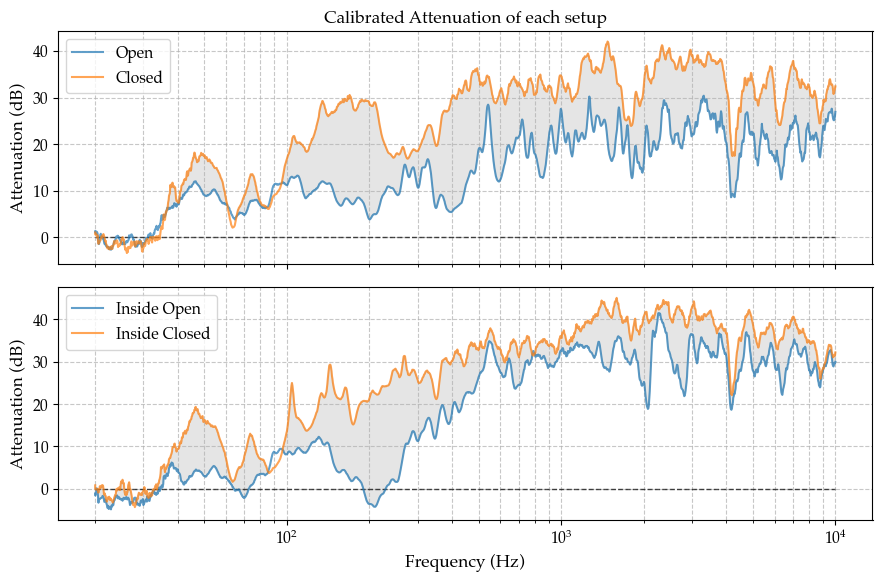

In [4]:
fig, ax = plt.subplots(2, figsize=(9, 6), sharex=True)

ax[0].hlines(0, xmin=limits[0], xmax=limits[1], color='k', linestyle='dashed', alpha=0.7, linewidth=1)
ax[1].hlines(0, xmin=limits[0], xmax=limits[1], color='k', linestyle='dashed', alpha=0.7, linewidth=1)

ax[0].plot(df['f_inst_hz'], -df['rms_0_open_cal (dB)'], label='Open', alpha=0.7)
ax[0].plot(df['f_inst_hz'], -df['rms_0_closed_cal (dB)'], label='Closed', alpha=0.7)
ax[0].fill_between(df['f_inst_hz'], -df['rms_0_closed_cal (dB)'], -df['rms_0_open_cal (dB)'], where=df['rms_0_closed_cal (dB)'] < df['rms_0_open_cal (dB)'], color='tab:grey', alpha=0.2)

ax[1].plot(df['f_inst_hz'], -df['rms_0_inside_open_cal (dB)'], label='Inside Open', alpha=0.7)
ax[1].plot(df['f_inst_hz'], -df['rms_0_inside_closed_cal (dB)'], label='Inside Closed', alpha=0.7)
ax[1].fill_between(df['f_inst_hz'], -df['rms_0_inside_closed_cal (dB)'], -df['rms_0_inside_open_cal (dB)'], where=df['rms_0_inside_closed_cal (dB)'] < df['rms_0_inside_open_cal (dB)'], color='tab:grey', alpha=0.2)

ax[0].set_xscale('log')
ax[1].set_xscale('log')

#plt.ylim(5e-1, 5e1)

ax[0].set_ylabel('Attenuation (dB)')
ax[1].set_ylabel('Attenuation (dB)')
ax[1].set_xlabel('Frequency (Hz)')

ax[0].grid(which='both', linestyle='--', alpha=0.7)
ax[1].grid(which='both', linestyle='--', alpha=0.7)

ax[0].legend()
ax[1].legend()

ax[0].set_title('Calibrated Attenuation of each setup')

plt.tight_layout()
#plt.savefig(f'fig/attenuation_calibrated.png', dpi=600)
plt.show()

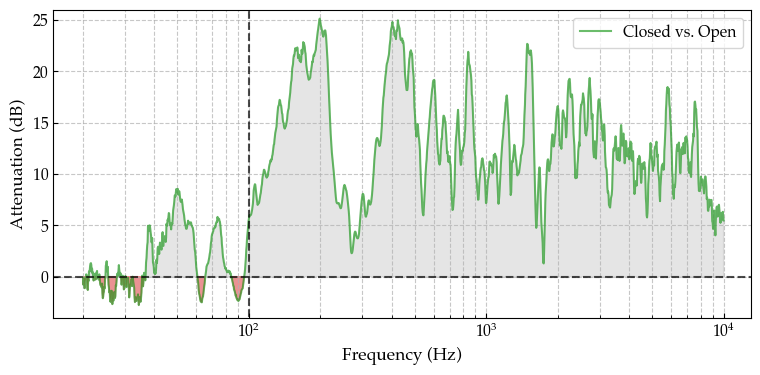

In [7]:
plt.figure(figsize=(9, 4))

xlim = (1.5e1, 1.3e4)

plt.plot(df['f_inst_hz'], -df['rms_0_closed_vs_open (dB)'], label='Closed vs. Open', alpha=0.7, color='tab:green')
#plt.plot(df['f_inst_hz'], df['rms_1_closed_vs_open (dB)'], label='Closed vs. Open (1)', alpha=0.7, color='tab:blue')

plt.fill_between(df['f_inst_hz'], -df['rms_0_closed_vs_open (dB)'], 0, where=df['rms_0_closed_vs_open (dB)'] < 0, color='tab:grey', alpha=0.2)
plt.fill_between(df['f_inst_hz'], -df['rms_0_closed_vs_open (dB)'], 0, where=df['rms_0_closed_vs_open (dB)'] > 0, color='tab:red', alpha=0.5)

plt.hlines(0, xmin=xlim[0], xmax=xlim[1], color='k', linestyle='dashed', alpha=0.7, linewidth=1.5)

plt.vlines(100, -5, 30, linestyles='dashed', alpha=0.7, color='k', linewidth=1.5)

#plt.hlines(-df_mean_low['rms_0_closed_vs_open (dB)'], xmin=xlim[0], xmax=xlim[1], color='tab:orange', linestyle='dashed', alpha=0.7, linewidth=1.5, label=f'Mean below 100 Hz: {-df_mean_low["rms_0_closed_vs_open (dB)"]:.1f} dB')
#plt.hlines(-df_mean_high['rms_0_closed_vs_open (dB)'], xmin=xlim[0], xmax=xlim[1], color='tab:orange', linestyle='dotted', alpha=0.7, linewidth=1.5, label=f'Mean above 100 Hz: {-df_mean_high["rms_0_closed_vs_open (dB)"]:.1f} dB')
#plt.hlines(-df['rms_0_closed_vs_open (dB)'].mean(), xmin=xlim[0], xmax=xlim[1], color='tab:orange', linestyle='solid', alpha=0.7, linewidth=1.5, label=f'Mean overall: {-df["rms_0_closed_vs_open (dB)"].mean():.1f} dB')

plt.xscale('log')

plt.ylabel('Attenuation (dB)')
plt.xlabel('Frequency (Hz)')

plt.ylim(-4, 26)

plt.tick_params(axis='both', which='both', direction='in')

plt.xlim(xlim)

plt.legend()
plt.grid(which='both', linestyle='--', alpha=0.7)
plt.savefig(f'fig/attenuation_closed_vs_open.pdf', dpi=600)
plt.show()

In [6]:
c_air = 343 # m/s
l_cov_cov = 0.56 # m
l_cov_passthrough = 2 * l_cov_cov # m
l_si_si = 0.48 # m
l_lid = 0.17 # m
l_lid_cov = 0.21 # m

l = {
    'cov_cov': l_cov_cov,
    'cov_passthrough': l_cov_passthrough,
    'si_si': l_si_si,
    'lid': l_lid,
    'lid_cov': l_lid_cov}

for key, length in l.items():
    f_res = c_air / (2 * length)
    print(f"{key}: {f_res:.1f} Hz")

cov_cov: 306.2 Hz
cov_passthrough: 153.1 Hz
si_si: 357.3 Hz
lid: 1008.8 Hz
lid_cov: 816.7 Hz
